This code is used to evaluate the energy distributions samples from the Conditional Real NVP. It aims at understanding both the change of bond and angle energies during the stretch of DNA, and what is the sample space the Conditional Real NVP built around the condition of end-to-end distance.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/'Colab Notebooks'/DNA_Final1
!ls

Mounted at /content/gdrive
/content/gdrive/MyDrive/Colab Notebooks/DNA_Final1
 0_Files		        energies_all_list15.json
 all_traj_DNAonly.npz	        energies_all_list_low-05.json
 checkpoints		        energies_all_list_low-15.json
 Conditional_RealNVP_v1.ipynb   energies.csv
 Conditional_RealNVP_v2.ipynb   Energies.ipynb
 cond_seq_0.pdb		        Energy_Eval.ipynb
 cond_seq_0_relaxed.pdb         eval_input.xyz
 cond_seq_100_relaxed.pdb       logs
 cond_seq_120_relaxed.pdb       merged_data.npz
 cond_seq_140_relaxed.pdb       mlp_seq_100.pdb
 cond_seq_1.5_1.pdb	        mlp_seq_120.pdb
 cond_seq_1.5_2.pdb	        mlp_seq_120_relaxed_1.pdb
 cond_seq_1.5_3.pdb	        mlp_seq_120_relaxed_2.pdb
 cond_seq_1.5_4.pdb	        mlp_seq_140.pdb
 cond_seq_1.5_5.pdb	        mlp_seq_140_unrelaxed.pdb
 cond_seq_1.5_6.pdb	       'RealNVP with MLP.ipynb'
 cond_seq_1.5.pdb	        results
 cond_seq_1.5_relaxed.pdb       stretch1.rst7
 cond_seq_-18_relaxed.pdb       stretch2.rst7
 cond_seq_18_relaxed.pdb

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

We define a few helper functions to load and analyse the energy results saved from the OpenMM minimisation runs.
load_list reads a JSON file into a Python list. extract_xy extracts the bond and angle energy terms, removes invalid entries, and optionally drops the largest outliers. add_cov_ellipse then adds a covariance ellipse to a plot so we can visualise the spread of each dataset in bond-angle energy space.

In [11]:
def load_list(path):
    with open(path, "r") as f:
        return json.load(f)

def extract_xy(records, k_outliers=100):
    bond = np.array([d.get("bond", np.nan) for d in records], dtype=float)
    angle = np.array([d.get("angle", np.nan) for d in records], dtype=float)

    mask = np.isfinite(bond) & np.isfinite(angle)
    bond, angle = bond[mask], angle[mask]

    if k_outliers and len(bond) > k_outliers:
        score = np.abs(bond) + np.abs(angle)
        keep = np.argsort(score)[:-k_outliers]
        bond, angle = bond[keep], angle[keep]

    return np.column_stack([bond, angle])

def add_cov_ellipse(ax, X, n_std=2.0, **kwargs):
    mean = X.mean(axis=0)
    cov = np.cov(X.T)

    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 1e-12)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)

    e = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(e)


We now load the saved JSON energy files for several different conditioning values (different DNA extension lengths). For each dataset, we extract the bond and angle energy terms and plot them as a scatter plot. We also overlay a covariance ellipse (2σ) to show the overall spread of each distribution and compare how the energy landscape changes across conditions.

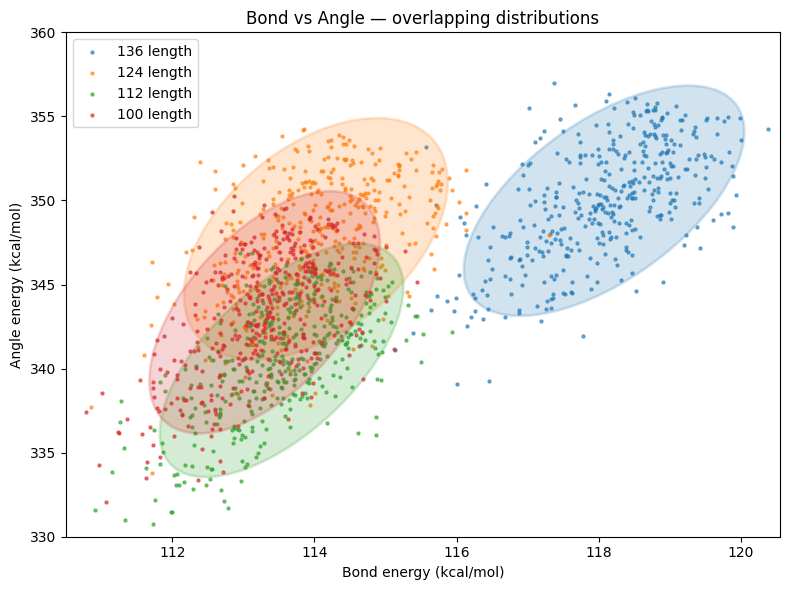

In [12]:
energies_05      = load_list("energies_all_list05.json")
energies_15      = load_list("energies_all_list15.json")
energies_low_05  = load_list("energies_all_list_low-05.json")
energies_low_15  = load_list("energies_all_list_low-15.json")

datasets = [
    ("136 length",      extract_xy(energies_15)),
    ("124 length",      extract_xy(energies_05)),
    ("112 length",  extract_xy(energies_low_05)),
    ("100 length",  extract_xy(energies_low_15)),
]


X_all = np.vstack([X for _, X in datasets])
xmin, xmax = 110.5, 120.55
ymin, ymax = 330.0, 360.0

fig, ax = plt.subplots(figsize=(8, 6))

for i, (name, X) in enumerate(datasets):
    c = f"C{i}"


    ax.scatter(X[:, 0], X[:, 1], s=18, marker=".", alpha=0.6, color=c, label=name)


    add_cov_ellipse(
        ax, X, n_std=2.0,
        facecolor=c, edgecolor=c, alpha=0.20, lw=2
    )

ax.set_xlabel("Bond energy (kcal/mol)")
ax.set_ylabel("Angle energy (kcal/mol)")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.legend(frameon=True, loc="best")
ax.set_title("Bond vs Angle — overlapping distributions")
plt.tight_layout()
plt.show()